In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [31]:
df = pd.read_csv('cleaned_data.csv')

In [33]:
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [35]:
X = df.drop('Engine Condition', axis=1)
y = df['Engine Condition']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
log_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])
log_model_pipeline.fit(X_train, y_train)
preds = log_model_pipeline.predict(X_test)
print('      Logistics Regression')
print(classification_report(y_test, preds))

rf_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])
rf_model_pipeline.fit(X_train, y_train)
rf_preds = rf_model_pipeline.predict(X_test)
print('       Random Forest')
print(classification_report(y_test, rf_preds))

gbc_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42))
])
gbc_model_pipeline.fit(X_train, y_train)
gbc_preds = gbc_model_pipeline.predict(X_test)
print('      Gradient Boosting')
print(classification_report(y_test, gbc_preds))

      Logistics Regression
              precision    recall  f1-score   support

           0       0.58      0.29      0.39      1444
           1       0.68      0.88      0.77      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.58      0.58      3907
weighted avg       0.64      0.66      0.63      3907

       Random Forest
              precision    recall  f1-score   support

           0       0.57      0.34      0.42      1444
           1       0.69      0.85      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.59      0.59      3907
weighted avg       0.64      0.66      0.64      3907

      Gradient Boosting
              precision    recall  f1-score   support

           0       0.57      0.38      0.45      1444
           1       0.70      0.83      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.61      3907
we

The comparative baseline evaluation highlights a clear trade-off between model architectures, with the Gradient Boosting Classifier achieving the highest operational sensitivity by capturing $38\%$ of minority class anomalies (Class 0 recall), outperforming Random Forest ($34\%$) and Logistic Regression ($29\%$). In predictive vehicle maintenance, Class 0 typically represents mechanical faults or engine failures; therefore, optimizing its recall is operationally critical to minimize missed failures (false negatives) that result in catastrophic vehicle breakdowns. While all three models sustain a stable overall accuracy of $66\%$ and strong precision on standard operating conditions (Class 1), the low baseline recall for anomalies underscores the complexity of the dataset's decision boundaries, validating why Gradient Boosting is selected as the production candidate for further tuning and threshold optimization.

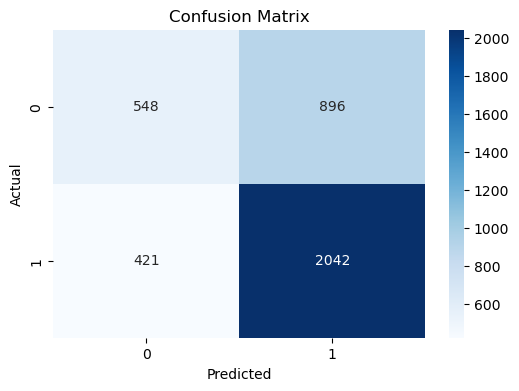

In [40]:
cm = confusion_matrix(y_test, gbc_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Conclusion

In predictive maintenance, undetected engine faults (False Negatives) are highly liabilities because they cause catastrophic on-road breakdowns and steep repair costs. While our baseline models reliably identify stable operations, they struggle with anomaly detection, capturing only 38% of actual failures. To make this system an effective asset-protection tool, next steps must focus on adjusting decision thresholds or applying class weights to aggressively minimize these missed failures

In [41]:
joblib.dump(gbc_model_pipeline, 'models/engine_condition_pipeline.pkl')

['models/engine_condition_pipeline.pkl']